In [16]:
import numpy as np
import torch
import networkx as nx
import open_clip
import matplotlib.pyplot as plt

In [2]:
graph = nx.read_graphml('output/cholecseg8k/video01_00080/graph/video01_00080_graph.graphml')

In [5]:
node_lf = [[graph.nodes.data()[str(j)][f'lang_feat_{i}'] for i in range(512)] for j in range(9)]
node_lf = torch.tensor(node_lf)
node_lf.shape

torch.Size([9, 512])

In [31]:
model, _, preprocess = open_clip.create_model_and_transforms('ViT-B-32', pretrained='laion2b_s34b_b79k')
model.eval()  # model in train mode by default, impacts some models with BatchNorm or stochastic depth active
tokenizer = open_clip.get_tokenizer('ViT-B-32')

reference_labels = ["gallbladder", "organ", "tissue", "anatomy", "surgery", "grasper", "tool", "blood", "stuff"]
# reference_labels = ["abdominal wall", "liver", "gastrointestinal tract", "fat", "grasper", "connective tissue", "blood", "cystic duct", "l-hook electrocautery", "gallbladder", "hepatic vein", "liver ligament"]
text = tokenizer(reference_labels)
with torch.no_grad(), torch.autocast("cuda"):
    text_features = model.encode_text(text)
    # text_features /= text_features.norm(dim=-1, keepdim=True)

    # text_probs = (100.0 * node_lf @ text_features.T).softmax(dim=-1) #type:ignore
    text_sim = torch.cosine_similarity(node_lf.unsqueeze(0), text_features.unsqueeze(1), dim=-1) #type:ignore
text_sim.shape

torch.Size([9, 9])

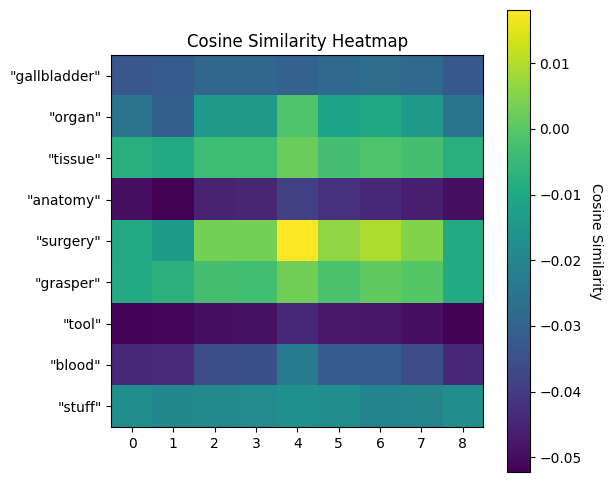

In [32]:
fig, ax = plt.subplots(figsize=(6, 6))
im = ax.imshow(text_sim, cmap="viridis")
# Set axis ticks and labels
ax.set_xticks(np.arange(9))
ax.set_yticks(np.arange(len(reference_labels)))
# ax.set_xticklabels([list_x])
ax.set_yticklabels([f'"{label}"' for label in reference_labels])

# Add a colorbar to the right
cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Cosine Similarity", rotation=270, labelpad=15)


plt.title("Cosine Similarity Heatmap")
plt.show()